## Introduction

The **Brownian Sheet** (also called the **Wiener Sheet** or **2D Brownian Motion**) is the natural two-parameter generalization of standard Brownian motion.

## Definition

A Brownian sheet $\{W(s,t) : s \geq 0, t \geq 0\}$ is a continuous Gaussian random field with:

|  Property  |  Formula  |
|-|-|
|  Zero at boundaries  |  $W(0,t) = W(s,0) = 0$  |
|  Zero mean  |  $\mathbb{E}[W(s,t)] = 0$  |
|  Covariance  |  $\text{Cov}\big(W(s_1,t_1), W(s_2,t_2)\big) = \min(s_1,s_2) \cdot \min(t_1,t_2)$  |


## Key Properties

1. 1D slices are Brownian motions: Fixing $t = t_0$, the process $W(s, t_0)$ is a standard BM scaled by $\sqrt{t_0}$. Similarly for fixed $s$.
2. Independent increments over disjoint rectangles: For a rectangle $R = [s_1, s_2] \times [t_1, t_2]$, the increment

$\Delta W(R) = W(s_2,t_2)-W(s_1,t_2)-W(s_2,t_1)+W(s_1,t_1)$

is Gaussian with mean 0 and variance equal to the area of the rectangle:

$Var[\Delta W(R)] = (s_2 - s_1)(t_2 - t_1)$

3. **Relation to white noise**: The Brownian sheet is the **integral** of 2D white noise. If \dot{W} is white noise, then

$W(s,t) = \displaystyle\int_{0}^{s} \displaystyle\int_{0}^{t} \dot{W}(u,v)dudv$

## Simulation Method

Discretize $[0,S] \times [0,T]$ into an $M \times N$ grid. Generate independent increments

$dW_{ij} \sim N(0,\Delta s . \Delta t)$

for each cell, then take the **2D cumulative sum**:

$W_{ij} = \displaystyle \sum_{a=1}^{i} \displaystyle\sum_{b=1}^{j} dW_{ab}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


def simulate_brownian_sheet(S, T, M, N, n_realizations=1):
    """
    Simulate Brownian sheet on [0,S] x [0,T].
    
    Uses independent Gaussian increments over cells and 2D cumulative summation.
    
    Parameters:
    -----------
    S, T : float       -- Domain bounds
    M, N : int         -- Number of cells in s and t directions
    n_realizations : int -- Number of independent sheets
    
    Returns:
    --------
    s : ndarray -- Grid points in s-direction, shape (M+1,)
    t : ndarray -- Grid points in t-direction, shape (N+1,)
    W : ndarray -- Sheet values, shape (n_realizations, M+1, N+1)
    """
    ds = S / M
    dt = T / N
    s = np.linspace(0, S, M + 1)
    t = np.linspace(0, T, N + 1)
    
    W = np.zeros((n_realizations, M + 1, N + 1))
    
    for k in range(n_realizations):
        # Independent increments over each cell
        dW = np.random.normal(0, np.sqrt(ds * dt), (M, N))
        # 2D cumulative sum to get sheet values at grid corners
        W[k, 1:, 1:] = np.cumsum(np.cumsum(dW, axis=0), axis=1)
    
    return s, t, W


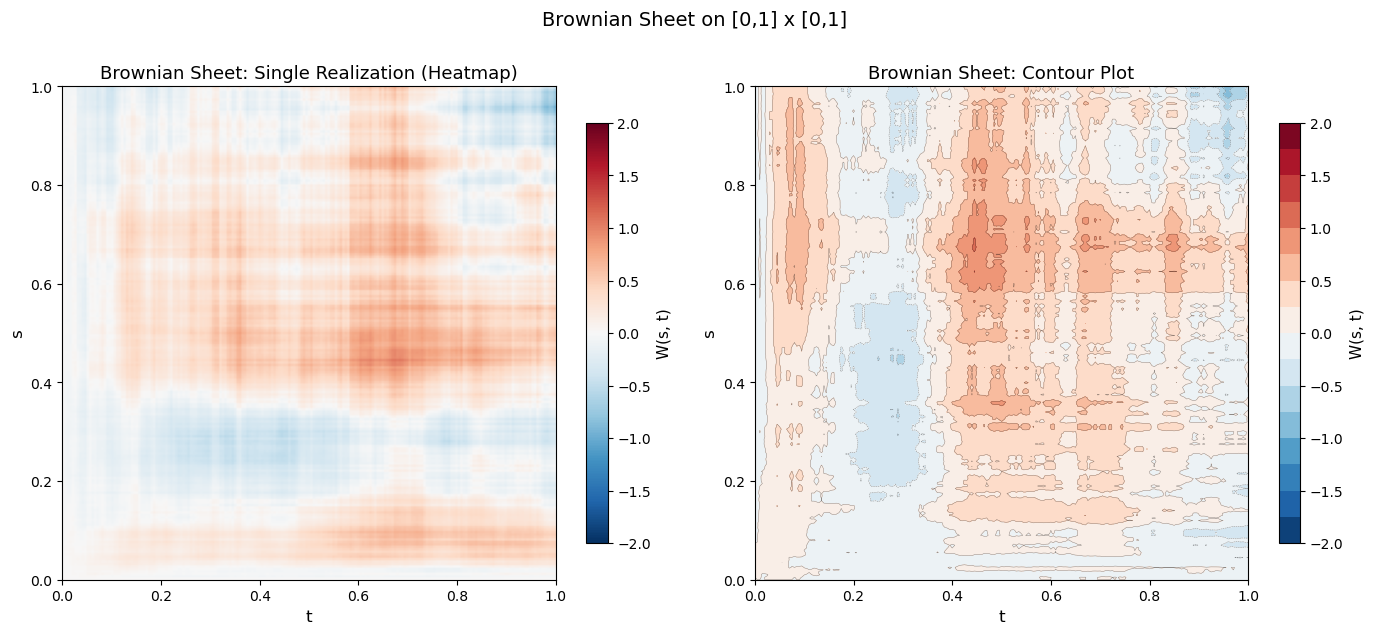

In [2]:
s, t, W = simulate_brownian_sheet(1.0, 1.0, 200, 200, n_realizations=1)
W0 = W[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(W0, origin='lower', extent=[0, 1, 0, 1], 
               cmap='RdBu_r', aspect='equal', vmin=-2, vmax=2)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('s', fontsize=12)
ax.set_title('Brownian Sheet: Single Realization (Heatmap)', fontsize=13)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('W(s, t)', fontsize=11)

# Contour plot
ax = axes[1]
S_grid, T_grid = np.meshgrid(s, t, indexing='ij')
levels = np.linspace(-2, 2, 17)
cont = ax.contourf(S_grid, T_grid, W0, levels=levels, cmap='RdBu_r')
ax.contour(S_grid, T_grid, W0, levels=levels, colors='black', linewidths=0.3, alpha=0.5)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('s', fontsize=12)
ax.set_title('Brownian Sheet: Contour Plot', fontsize=13)
ax.set_aspect('equal')
cbar2 = plt.colorbar(cont, ax=ax, shrink=0.8)
cbar2.set_label('W(s, t)', fontsize=11)

plt.suptitle('Brownian Sheet on [0,1] x [0,1]', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


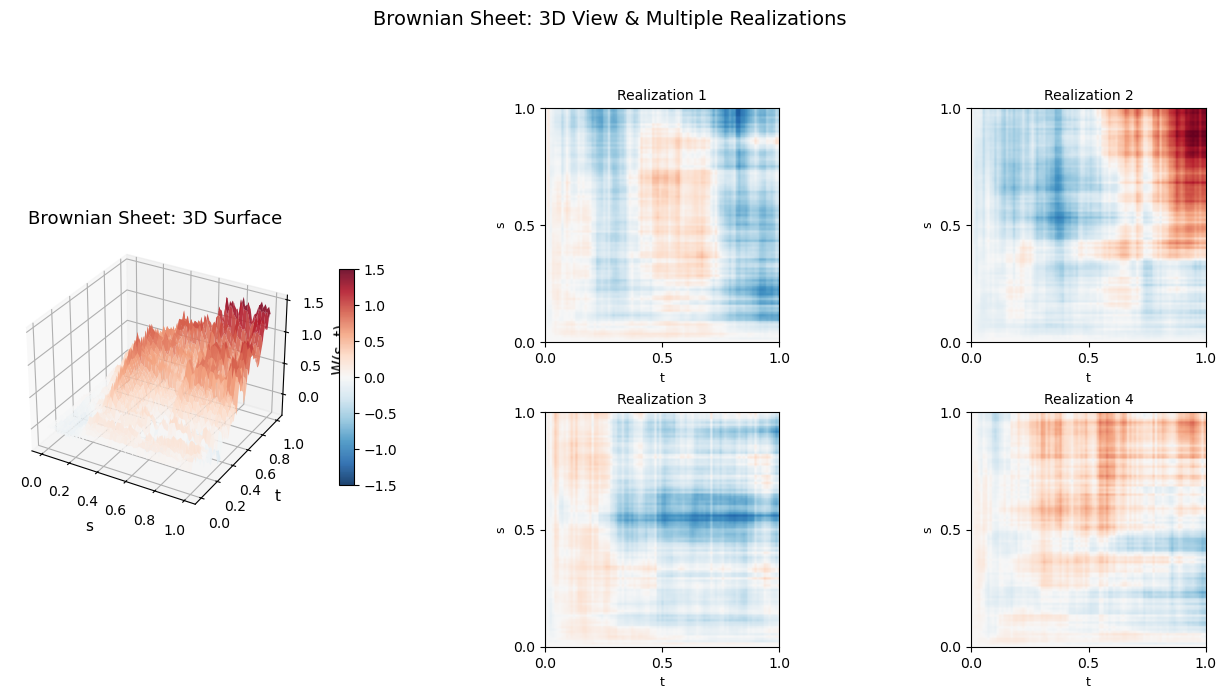

In [3]:
fig = plt.figure(figsize=(16, 7))

# 3D Surface on the left
gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[:, 0], projection='3d')
s, t, W = simulate_brownian_sheet(1.0, 1.0, 80, 80, n_realizations=1)
S_grid, T_grid = np.meshgrid(s, t, indexing='ij')

surf = ax1.plot_surface(S_grid, T_grid, W[0], cmap='RdBu_r', 
                        linewidth=0, antialiased=True, alpha=0.9,
                        vmin=-1.5, vmax=1.5)
ax1.set_xlabel('s', fontsize=11)
ax1.set_ylabel('t', fontsize=11)
ax1.set_zlabel('W(s, t)', fontsize=11)
ax1.set_title('Brownian Sheet: 3D Surface', fontsize=13)
fig.colorbar(surf, ax=ax1, shrink=0.4, aspect=15, pad=0.1)

# Four realizations on the right
s2, t2, W_multi = simulate_brownian_sheet(1.0, 1.0, 100, 100, n_realizations=4)
positions = [(0, 1), (0, 2), (1, 1), (1, 2)]
titles = ['Realization 1', 'Realization 2', 'Realization 3', 'Realization 4']

for idx, (pos, title) in enumerate(zip(positions, titles)):
    ax_in = fig.add_subplot(gs[pos[0], pos[1]])
    im = ax_in.imshow(W_multi[idx], origin='lower', extent=[0, 1, 0, 1],
                      cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    ax_in.set_title(title, fontsize=10)
    ax_in.set_xlabel('t', fontsize=9)
    ax_in.set_ylabel('s', fontsize=9)
    ax_in.set_xticks([0, 0.5, 1])
    ax_in.set_yticks([0, 0.5, 1])

plt.suptitle('Brownian Sheet: 3D View & Multiple Realizations', fontsize=14, y=1.02)
plt.savefig('brownian_sheet_3d_multi.png', dpi=150, bbox_inches='tight')
plt.show()


## Why the Covariance Structure Matters

The covariance $\min(s_1,s_2)\min(t_1,t_2)$ is the defining feature. It implies:

- **Correlation decays slowly** — points far apart in either direction remain correlated
- **The sheet is "smooth" in a statistical sense** — unlike white noise, nearby points are highly correlated
- **The 2D cumulative sum construction naturally** enforces this because overlapping rectangles share increments

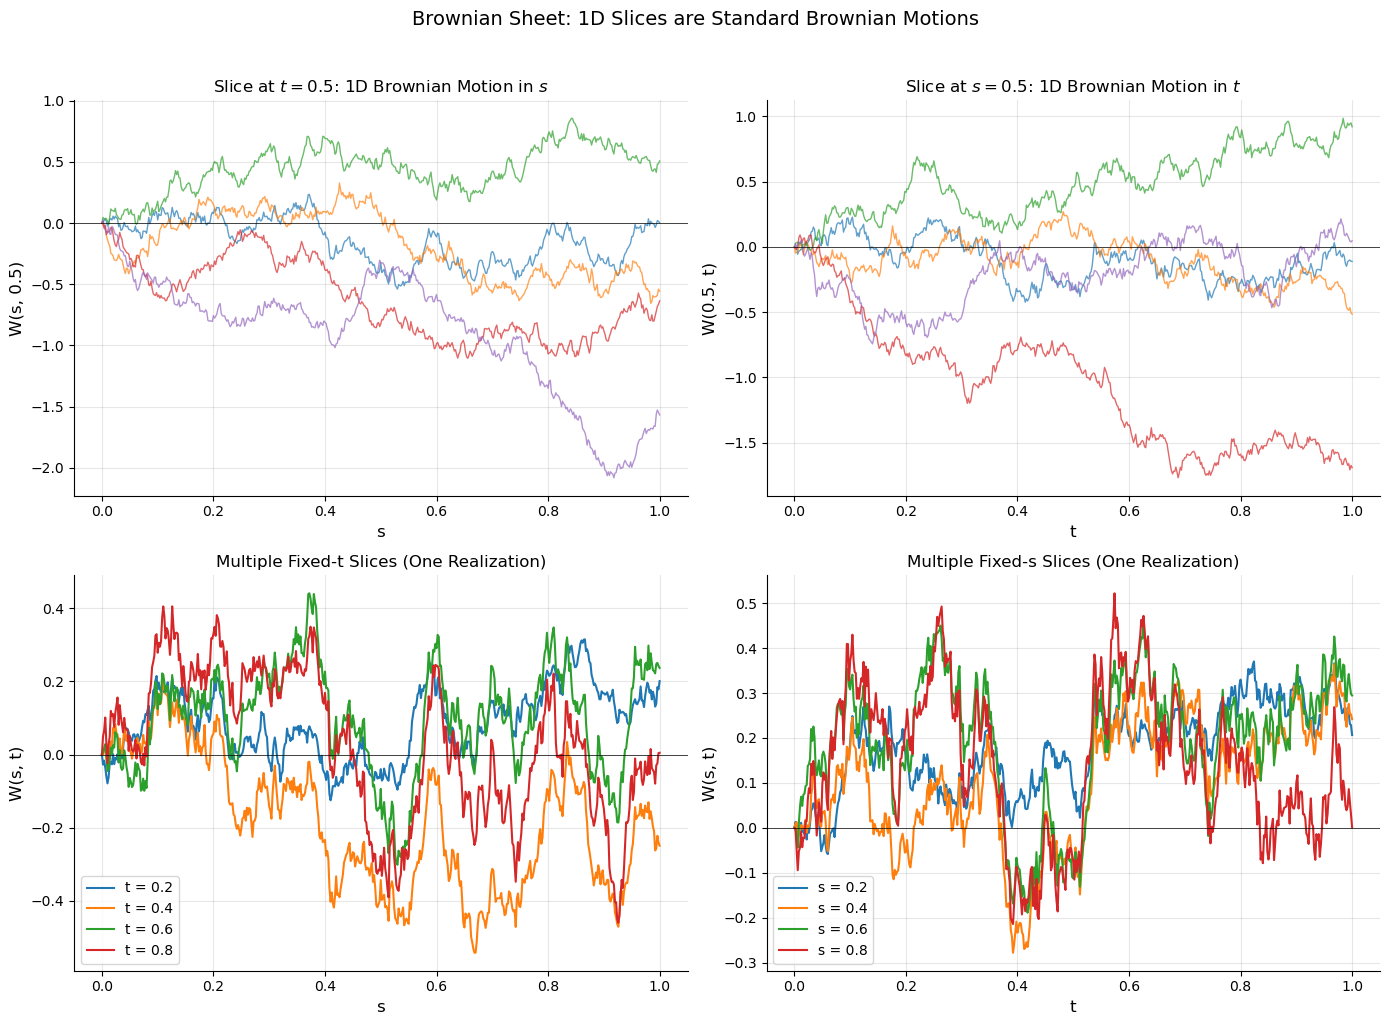

In [4]:
s, t, W = simulate_brownian_sheet(1.0, 1.0, 500, 500, n_realizations=5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: Fix t = 0.5, vary s
ax = axes[0, 0]
idx_t = len(t) // 2
for k in range(5):
    ax.plot(s, W[k, :, idx_t], alpha=0.7, lw=1)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('s', fontsize=12)
ax.set_ylabel('W(s, 0.5)', fontsize=12)
ax.set_title(r'Slice at $t = 0.5$: 1D Brownian Motion in $s$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Top right: Fix s = 0.5, vary t
ax = axes[0, 1]
idx_s = len(s) // 2
for k in range(5):
    ax.plot(t, W[k, idx_s, :], alpha=0.7, lw=1)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('W(0.5, t)', fontsize=12)
ax.set_title(r'Slice at $s = 0.5$: 1D Brownian Motion in $t$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bottom left: Multiple fixed-t slices on one sheet
ax = axes[1, 0]
W0 = W[0]
t_fixed = [0.2, 0.4, 0.6, 0.8]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for tval, color in zip(t_fixed, colors):
    idx = int(tval * len(t))
    ax.plot(s, W0[:, idx], color=color, lw=1.5, label='t = %.1f' % tval)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('s', fontsize=12)
ax.set_ylabel('W(s, t)', fontsize=12)
ax.set_title('Multiple Fixed-t Slices (One Realization)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bottom right: Multiple fixed-s slices on one sheet
ax = axes[1, 1]
s_fixed = [0.2, 0.4, 0.6, 0.8]
for sval, color in zip(s_fixed, colors):
    idx = int(sval * len(s))
    ax.plot(t, W0[idx, :], color=color, lw=1.5, label='s = %.1f' % sval)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('W(s, t)', fontsize=12)
ax.set_title('Multiple Fixed-s Slices (One Realization)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Brownian Sheet: 1D Slices are Standard Brownian Motions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Slices Interpretation

When you fix one parameter, the resulting 1D process is a scaled Brownian motion:
 
- $W(s, t_0)$ has variance $s \cdot t_0$, so it's a BM with variance parameter $t_0$
- The paths look like standard Brownian motion but with volatility $\sqrt{t_0}$
- Higher fixed values $(t = 0.8 vs t = 0.2)$ produce more dispersed paths

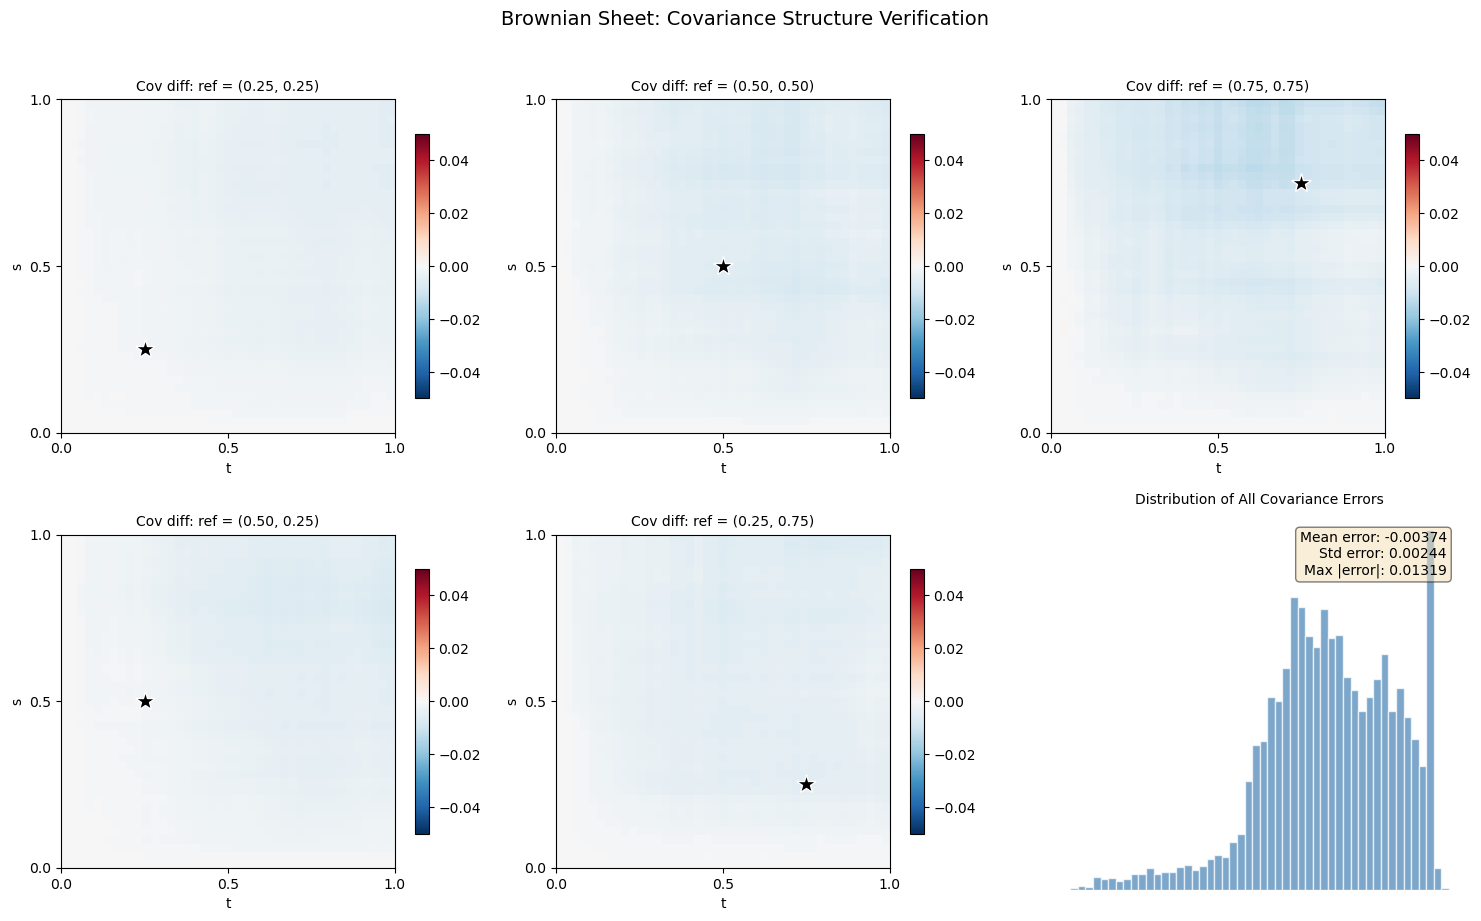

In [5]:
n_mc = 20000
M, N = 40, 40
s_grid, t_grid, W_mc = simulate_brownian_sheet(1.0, 1.0, M, N, n_realizations=n_mc)

ref_points = [(10, 10), (20, 20), (30, 30), (20, 10), (10, 30)]
ref_coords = [(s_grid[i], t_grid[j]) for i, j in ref_points]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, ((si, ti), (sc, tc)) in enumerate(zip(ref_points, ref_coords)):
    ax = axes[idx]
    
    W_ref = W_mc[:, si, ti]
    empirical_cov = np.zeros((M + 1, N + 1))
    for i in range(M + 1):
        for j in range(N + 1):
            empirical_cov[i, j] = np.mean(
                (W_mc[:, i, j] - np.mean(W_mc[:, i, j])) * (W_ref - np.mean(W_ref))
            )
    
    theoretical_cov = np.zeros((M + 1, N + 1))
    for i in range(M + 1):
        for j in range(N + 1):
            theoretical_cov[i, j] = min(s_grid[i], sc) * min(t_grid[j], tc)
    
    diff = empirical_cov - theoretical_cov
    im = ax.imshow(diff, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r',
                   vmin=-0.05, vmax=0.05)
    ax.plot(tc, sc, 'k*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    ax.set_xlabel('t', fontsize=10)
    ax.set_ylabel('s', fontsize=10)
    ax.set_title('Cov diff: ref = (%.2f, %.2f)' % (sc, tc), fontsize=10)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    plt.colorbar(im, ax=ax, shrink=0.7)

# Summary stats
ax = axes[-1]
ax.axis('off')
all_diffs = []
for (si, ti), (sc, tc) in zip(ref_points, ref_coords):
    W_ref = W_mc[:, si, ti]
    for i in range(M + 1):
        for j in range(N + 1):
            emp = np.mean((W_mc[:, i, j] - np.mean(W_mc[:, i, j])) * (W_ref - np.mean(W_ref)))
            theo = min(s_grid[i], sc) * min(t_grid[j], tc)
            all_diffs.append(emp - theo)

ax.hist(all_diffs, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax.set_title('Distribution of All Covariance Errors', fontsize=10)
ax.set_xlabel('Empirical - Theoretical')
ax.set_ylabel('Count')

stats_text = ('Mean error: %.5f\nStd error: %.5f\nMax |error|: %.5f' % 
              (np.mean(all_diffs), np.std(all_diffs), np.max(np.abs(all_diffs))))
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Brownian Sheet: Covariance Structure Verification', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


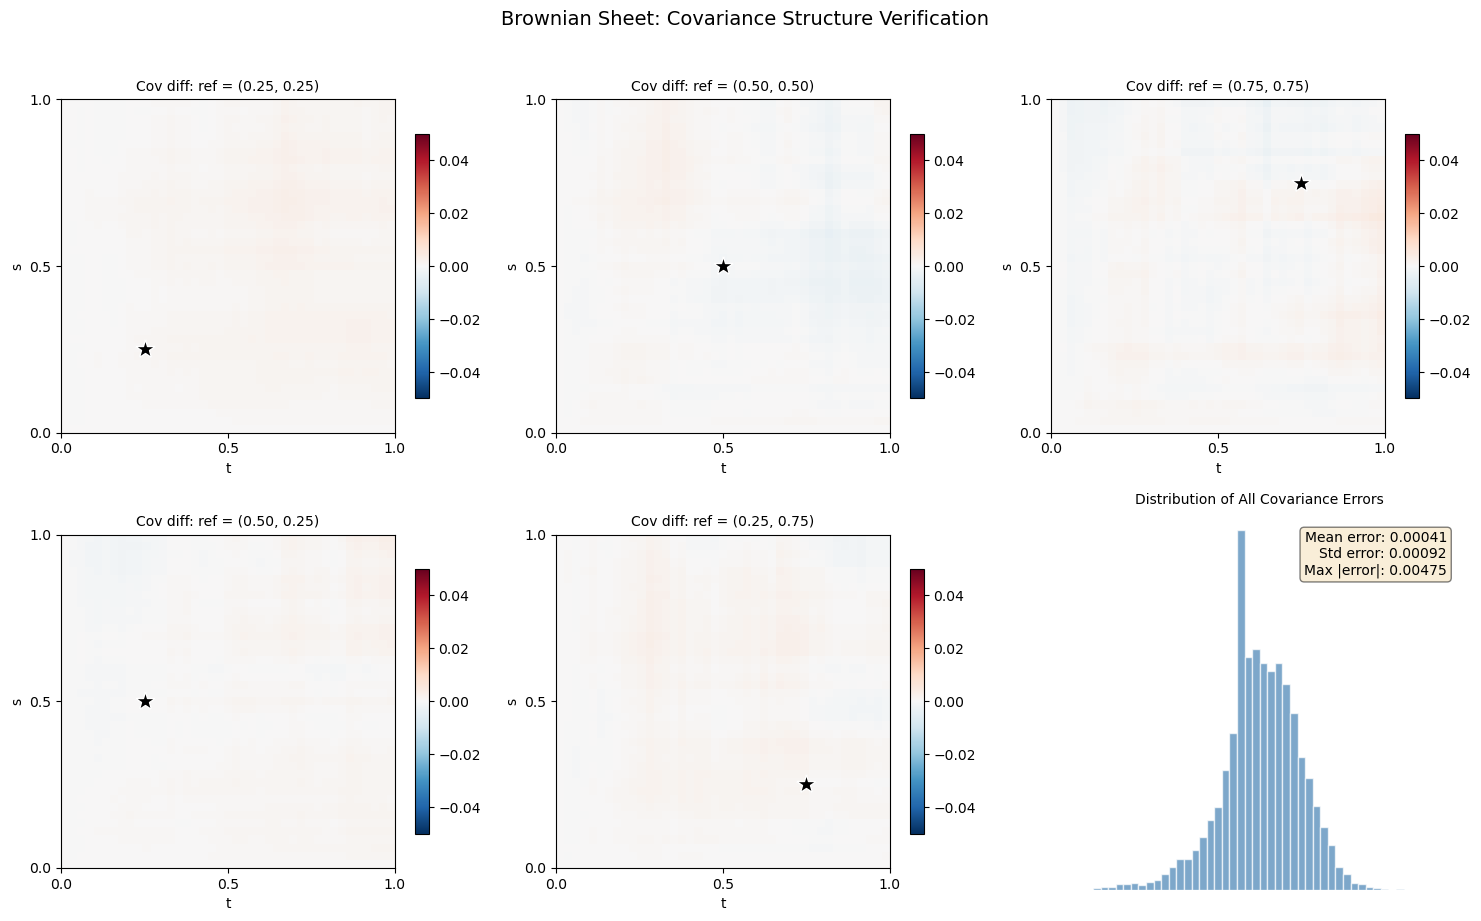

In [7]:
n_mc = 20000
M, N = 40, 40
s_grid, t_grid, W_mc = simulate_brownian_sheet(1.0, 1.0, M, N, n_realizations=n_mc)

ref_points = [(10, 10), (20, 20), (30, 30), (20, 10), (10, 30)]
ref_coords = [(s_grid[i], t_grid[j]) for i, j in ref_points]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, ((si, ti), (sc, tc)) in enumerate(zip(ref_points, ref_coords)):
    ax = axes[idx]
    W_ref = W_mc[:, si, ti]
    
    empirical_cov = np.zeros((M + 1, N + 1))
    for i in range(M + 1):
        for j in range(N + 1):
            empirical_cov[i, j] = np.mean(
                (W_mc[:, i, j] - np.mean(W_mc[:, i, j])) * (W_ref - np.mean(W_ref))
            )
    
    theoretical_cov = np.zeros((M + 1, N + 1))
    for i in range(M + 1):
        for j in range(N + 1):
            theoretical_cov[i, j] = min(s_grid[i], sc) * min(t_grid[j], tc)
    
    diff = empirical_cov - theoretical_cov
    im = ax.imshow(diff, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r',
                   vmin=-0.05, vmax=0.05)
    ax.plot(tc, sc, 'k*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    ax.set_xlabel('t', fontsize=10)
    ax.set_ylabel('s', fontsize=10)
    ax.set_title('Cov diff: ref = (%.2f, %.2f)' % (sc, tc), fontsize=10)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    plt.colorbar(im, ax=ax, shrink=0.7)

# Summary stats
ax = axes[-1]
ax.axis('off')
all_diffs = []
for (si, ti), (sc, tc) in zip(ref_points, ref_coords):
    W_ref = W_mc[:, si, ti]
    for i in range(M + 1):
        for j in range(N + 1):
            emp = np.mean((W_mc[:, i, j] - np.mean(W_mc[:, i, j])) * (W_ref - np.mean(W_ref)))
            theo = min(s_grid[i], sc) * min(t_grid[j], tc)
            all_diffs.append(emp - theo)

ax.hist(all_diffs, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax.set_title('Distribution of All Covariance Errors', fontsize=10)
ax.set_xlabel('Empirical - Theoretical')
ax.set_ylabel('Count')

stats_text = ('Mean error: %.5f\nStd error: %.5f\nMax |error|: %.5f' % 
              (np.mean(all_diffs), np.std(all_diffs), np.max(np.abs(all_diffs))))
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Brownian Sheet: Covariance Structure Verification', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## The Independent Increment Property

For **disjoint rectangles**, the increments are independent. For a single rectangle

$R = [s_1,s_2] \times [t_1,t_2]:$

$\Delta W(R) \sim N(0, (s_2 - s_1)(t_2 - t_1))$


This is the 2D analogue of $\Delta W \sim \mathcal{N}(0, \Delta t)$ for 1D Brownian motion. The variance equals the area of the rectangle.

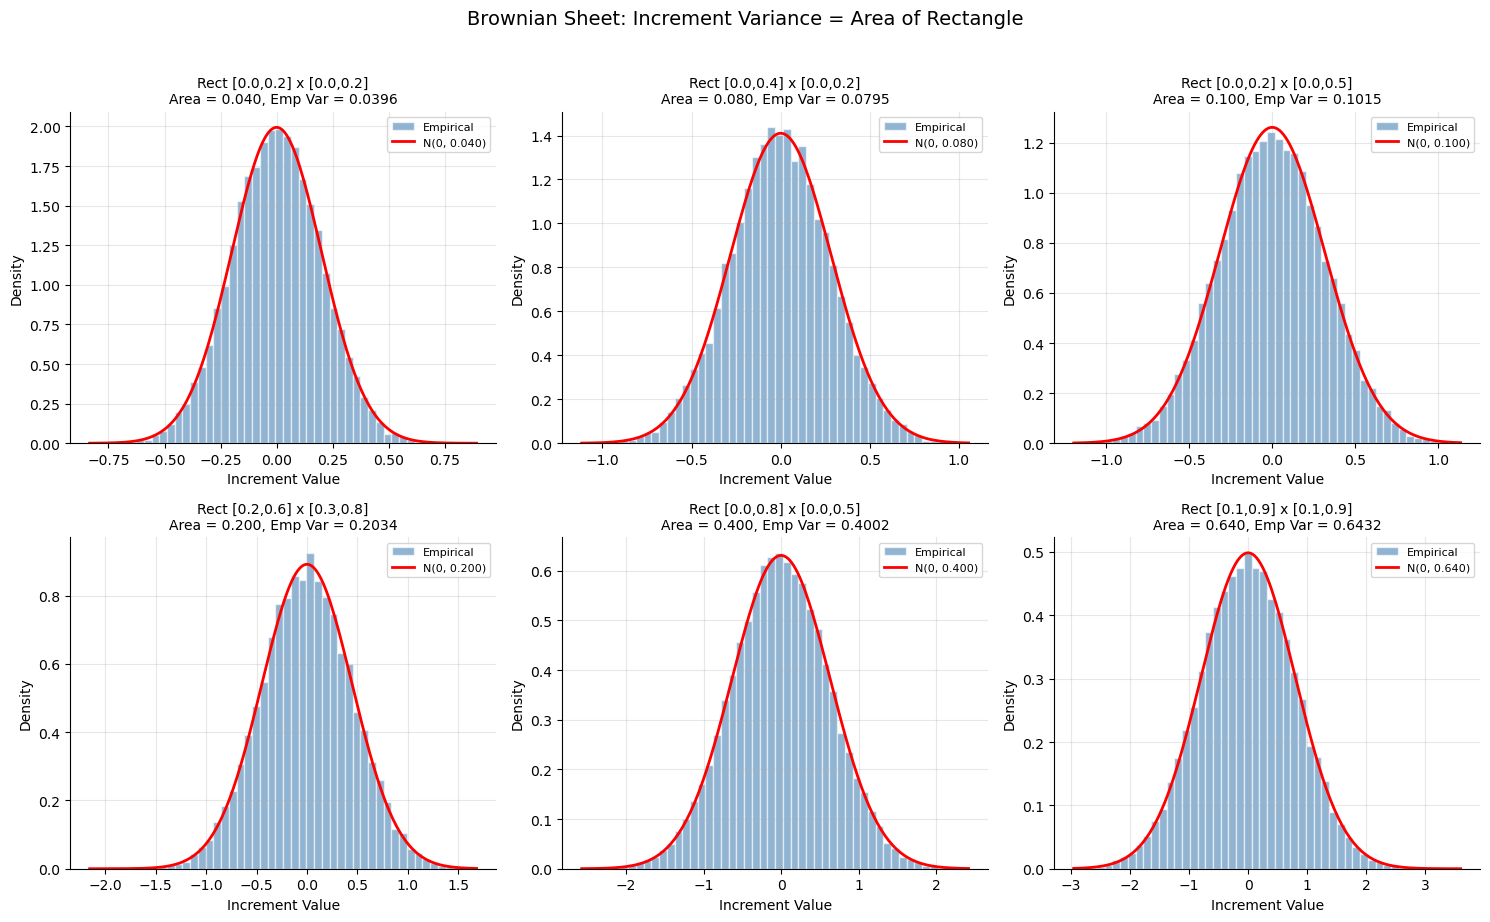

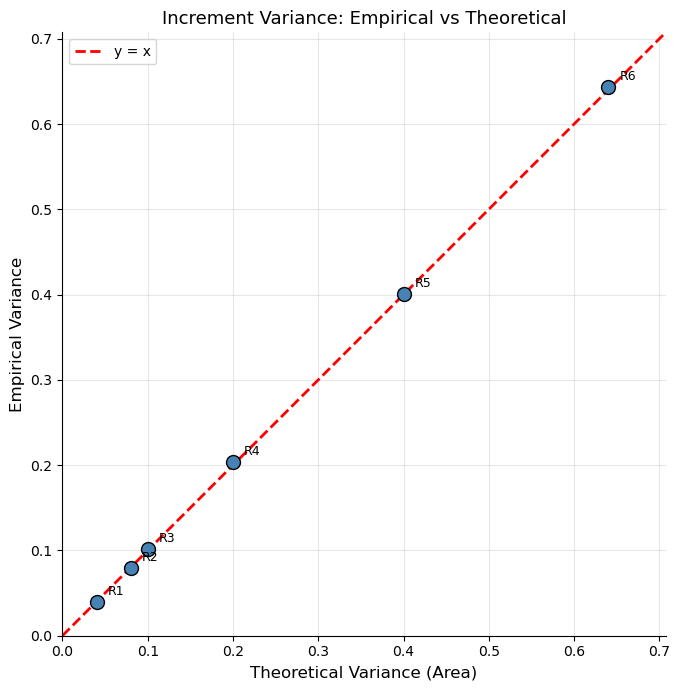

In [6]:
n_mc_inc = 20000
M, N = 40, 40
s_inc, t_inc, W_inc = simulate_brownian_sheet(1.0, 1.0, M, N, n_realizations=n_mc_inc)

rectangles = [
    (0.0, 0.2, 0.0, 0.2),
    (0.0, 0.4, 0.0, 0.2),
    (0.0, 0.2, 0.0, 0.5),
    (0.2, 0.6, 0.3, 0.8),
    (0.0, 0.8, 0.0, 0.5),
    (0.1, 0.9, 0.1, 0.9),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

empirical_vars = []
theoretical_vars = []

for idx, (s1, s2, t1, t2) in enumerate(rectangles):
    ax = axes[idx]
    i1, i2 = int(s1 * M), int(s2 * M)
    j1, j2 = int(t1 * N), int(t2 * N)
    
    delta_W = (W_inc[:, i2, j2] - W_inc[:, i1, j2] 
               - W_inc[:, i2, j1] + W_inc[:, i1, j1])
    
    emp_var = np.var(delta_W, ddof=1)
    theo_var = (s2 - s1) * (t2 - t1)
    empirical_vars.append(emp_var)
    theoretical_vars.append(theo_var)
    
    ax.hist(delta_W, bins=50, density=True, alpha=0.6, color='steelblue',
            edgecolor='white', label='Empirical')
    
    x_range = np.linspace(delta_W.min(), delta_W.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(theo_var)), 
            'r-', lw=2, label='N(0, %.3f)' % theo_var)
    
    title_text = 'Rect [%.1f,%.1f] x [%.1f,%.1f]\nArea = %.3f, Emp Var = %.4f' % (s1, s2, t1, t2, theo_var, emp_var)
    ax.set_title(title_text, fontsize=10)
    ax.set_xlabel('Increment Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Brownian Sheet: Increment Variance = Area of Rectangle', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary scatter
fig2, ax2 = plt.subplots(figsize=(7, 7))
ax2.scatter(theoretical_vars, empirical_vars, s=100, c='steelblue', edgecolors='black', zorder=3)
max_val = max(max(theoretical_vars), max(empirical_vars)) * 1.1
ax2.plot([0, max_val], [0, max_val], 'r--', lw=2, label='y = x')
for i, (tv, ev) in enumerate(zip(theoretical_vars, empirical_vars)):
    ax2.annotate('R%d' % (i+1), (tv, ev), textcoords="offset points", 
                 xytext=(8, 5), fontsize=9)
ax2.set_xlabel('Theoretical Variance (Area)', fontsize=12)
ax2.set_ylabel('Empirical Variance', fontsize=12)
ax2.set_title('Increment Variance: Empirical vs Theoretical', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val)
ax2.set_aspect('equal')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## BROWNIAN SHEET

|  Definition:  |  W(s,t) = integral_0^s integral_0^t dW(u,v) where dW(u,v) are independent N(0, du*dv) increments  |
|-|-|
|  Mean:  |  $E[W(s,t)] = 0$  |
|  Covariance:  |  Cov(W(s1,t1), W(s2,t2)) = min(s1,s2) * min(t1,t2)  |
|  Increment:  |  For R = [s1,s2] x [t1,t2]: Delta W(R) ~ N(0, (s2-s1)*(t2-t1)) |
|  1D slices:  |  W(s, t0) is BM with variance parameter t0 W(s0, t) is BM with variance parameter s0  |
|  Simulation:  |  1. Generate dW[i,j] ~ N(0, ds*dt) for each cell 2. W = cumsum(cumsum(dW, axis=0), axis=1) 3. Pad with zeros on left/bottom boundaries  |

|  Feature  |  Brownian Sheet	2D White Noise  |
|-|-|
|  Definition  |  Integrated white noise	Uncorrelated Gaussian field	 |
|  Correlation  |  Strong spatial correlation	Zero correlation everywhere  |	
|  Visual  |  Smooth, blob-like patterns	Grainy, salt-and-pepper  |
|  Variance at point  |  Grows with s \cdot t	Constant everywhere	 |
|  Derivative  |  Does not exist (too rough)	Formal object only  |
|  Use case  |  Random surfaces, SPDEs, image analysis	Residuals, noise modeling  |